# Lindholm at al Replication

<center> <h1> <span style="color:black"> IA|BE Data Science Certificate - Module 3 - Computer lab 4  </h1> </center> 
<center> <h2> <span style="color:red"> Fairness and discrimination-free pricing </h1> </center>

# Agenda

* [Chapter 1 - Introduction to fairness](#one)
    + [1.1 Bias or fairness?](#one-one)
    + [1.2 Problem definition and mitigation](#one-two)
* [Chapter 2 - Discrimination-free pricing](#two)
    + [2.1 Methodology](#two-one)
    + [2.2 Synthetic data generation](#two-one)
    + [2.3 Model fitting](#two-one)
    + [2.4 Plot interpretation](#two-three)
* [Chapter 3 - Discrimination-free prices using XGBoost](#three)
  + [3.1 -](#three-one)
  + [3.2 -](#three-two)

M. Lindholm, R. Richman, A. Tsanakas, M.V. Wüthrich. (2021). Discrimination-free insurance pricing. ([LINK](https://www.cambridge.org/core/journals/astin-bulletin-journal-of-the-iaa/article/discriminationfree-insurance-pricing/ED25C4053690E56050F437B8DF2AD117))

# Chapter 1 - Introduction to fairness <a name="one"></a>

## Bias or fairness? <a name="one-one"></a>

In the last few years, we witnessed an increasing focus on statistical learning/machine learning systems that are ethical and fair. **bias** and **fairness** are two terms on which researchers are working to answer regulatory and business necessities. The two terms are often used exchangeably, yet they convey a slightly different message.



* **Bias**: "inclination or prejudice for or against one person or group, especially in a way considered to be unfair." - Oxford Living Dictionaries.
    * How far away is a truly random dataset from our given dataset?  - positive definition of bias as it represents the pattern in the data structure that the statistical model learns.
    * Statistical bias - the model does not capture the data generating process of the underlying variable.
    * Colloquial use of the term bias - a biased model produces unfair results.

* **Fairness**: "impartial and just treatment or behaviour without favouritism or discrimination." - Oxford Living Dictionaries
    * Group fairness
        * Demographic parity (or statistical parity)
        * Equalized odds
    * Individual fairness


## Problem definition and mitigation<a name="one-one"></a>

* Generally, the aim of the actuary/statistician is to build a model that approxiamte reality as close as possible. When we feed a loss function to a model, we are asking for **maximizing accuracy** according to some criteria. E.g., this is reflected in the MSE loss function:

$$\frac{1}{n}\sum_{i=1}^{n}{(y_{i}-\hat{y}_{i})^{2}}$$

* **"Technology is neither good nor bad; nor is it neutral"**, and **"Technology’s interaction with the social ecology is such that technical developments frequently have environmental, social, and human consequences that go far beyond the immediate purposes of the technical devices and practices themselves, and technology can have quite different results when introduced into different contexts or under different circumstances"**, [Kranzberg (1986)](https://www.jstor.org/stable/3105385).

* We cannot expect technology to be neutral (bias-free) if we don't explicitly ask for it:
    * Accuracy: $\pi(x)=\mathbb{E}_{\mathbb{P}}{[Y|X=x]}$, ($\mathbb{P}$ historical probability)
    * Fairness: $\pi^{*}(x)=\mathbb{E}_{\mathbb{P^{*}}}{[Y|X=x]}$, ($\mathbb{P^{*}}$ targeted probability)

[PICTURE HERE]

In [204]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Chapter 2 - Discrimination-free prices <a name="two"></a>

$\textbf{X} = (X_{1}, X_{2})$, where 
* $X_{1}\in \left \{ 15,...,80 \right \}$ is age of policy holder
* $X_{2}\in \left \{ non-smoker, smoker \right \}$
* we assume that smoking habits are gender related

In [3]:
age_range = np.arange(start = 15, stop = 81, step = 1); age_range

array([15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31,
       32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48,
       49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65,
       66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80])

In [4]:
age_range.shape

(66,)

In [5]:
pregnant_age_range = np.repeat(0,66)
pregnant_age_range[6:26] = 1
pregnant_age_range.shape
pregnant_age_range

array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

We consider 3 different types of health costs:
1. birth related health costs only affecting women between age 20 and 40 (type 1)
$$log\lambda_{1}(\textbf{X},D):=\alpha_{0}+\alpha_{1}1_{X_1\in[20,40]}1_{D=woman}$$

2. cancer related health costs with higher frequency for smokers and women
$$log\lambda_{2}(\textbf{X},D):=\beta_{0}+\beta_{1}X_{1}+\beta_{2}1_{X_2=smoker} + \beta_{3}1_{D=woman}$$

3. health costs due to other disabilities
$$log\lambda_{3}(\textbf{X},D):=\gamma_{0}+\gamma_{1}X_{1}$$

##### 1.2 DEF - Best-Estimate Price (BEP)

$$\mu{(\textbf{X},D)} = C_{1}\lambda_{1}(\textbf{X},D) + C_{2}\lambda_{2}(\textbf{X},D) + C_{3}\lambda_{3}(\textbf{X},D)$$
The best estimate prices are obtained using the following parametrization:
* $(\alpha_{0},\alpha_{1})=(-40,38.5)$
* $(\beta_{0},\beta_{1},\beta_{2},\beta_{3})=(-2,0.004,0.1,0.2)$
* $(\gamma_{0},\gamma_{1})=(-2,0.01)$

### 2. Estimation of Best-Estimate Prices

##### 2.1 Best-estimate price: male + non-smoker

In [6]:
type1_m_ns = np.exp(-40)
type2_m_ns = np.exp(-2 + 0.004*age_range)
type3_m_ns = np.exp(-2 + 0.01*age_range)

In [7]:
print(type1_m_ns.shape, type2_m_ns.shape, type3_m_ns.shape)

() (66,) (66,)


In [8]:
best_est_m_ns = 0.5*type1_m_ns + 0.9*type2_m_ns + 0.1*type3_m_ns

##### 2.2 Best-estimate price: male + smoker

In [9]:
type1_m_s = np.exp(-40)
type2_m_s = np.exp(-2 + 0.004*age_range + 0.1)
type3_m_s = np.exp(-2 + 0.01*age_range)

In [10]:
print(type1_m_s.shape, type2_m_s.shape, type3_m_s.shape)

() (66,) (66,)


In [11]:
best_est_m_s = 0.5*type1_m_s + 0.9*type2_m_s + 0.1*type3_m_s

##### 2.3 Best-estimate price: female + non-smoker

In [12]:
type1_f_ns = np.exp(-40 + 38.5*pregnant_age_range)
type2_f_ns = np.exp(-2 + 0.004*age_range + 0.2)
type3_f_ns = np.exp(-2 + 0.01*age_range)

In [13]:
print(type1_f_ns.shape, type2_f_ns.shape, type3_f_ns.shape)

(66,) (66,) (66,)


In [14]:
best_est_f_ns = 0.5*type1_f_ns + 0.9*type2_f_ns + 0.1*type3_f_ns

##### 2.4 Best-estimate price: female + smoker

In [15]:
type1_f_s = np.exp(-40 + 38.5*pregnant_age_range)
type2_f_s = np.exp(-2 + 0.004*age_range + 0.1 + 0.2)
type3_f_s = np.exp(-2 + 0.01*age_range)

In [16]:
best_est_f_s = 0.5*type1_f_s + 0.9*type2_f_s + 0.1*type3_f_s

##### 2.5 Plot Best-estimate Price: smoker vs non-smoker

In [72]:
num_rows = 20
years = list(range(1990, 1990 + num_rows))
data_preproc = pd.DataFrame({
    'age': age_range, 
    'best-estimate price men non-smoking': best_est_m_ns,
    'best-estimate price men smoking': best_est_m_s,
    'best-estimate price women non-smoking': best_est_f_ns,
    'best_estimate price women smoking': best_est_f_s})

data_preproc.describe()

,age,best-estimate price men non-smoking,best-estimate price men smoking,best-estimate price women non-smoking,best_estimate price women smoking
count,66.000000,66.000000,66.000000,66.000000,66.000000
mean,47.500000,0.169876,0.185411,0.236388,0.255363
std,19.196354,0.015570,0.016762,0.043504,0.043111
min,15.000000,0.145057,0.158659,0.173692,0.190306
25%,31.250000,0.156518,0.171034,0.205212,0.224418
50%,47.500000,0.169051,0.184542,0.221463,0.241959
75%,63.750000,0.182783,0.199314,0.292322,0.309528
max,80.000000,0.197856,0.215497,0.306337,0.324698


<AxesSubplot:xlabel='age', ylabel='value'>

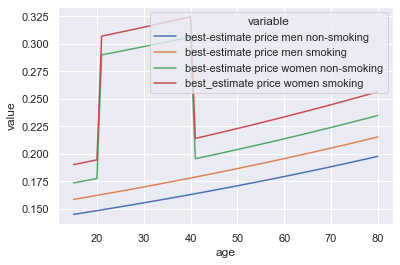

In [73]:
sns.lineplot(x='age', y='value', hue='variable', 
             data=pd.melt(data_preproc, ['age']))

### 3. Estimation of Unawarness Prices

Exploiting Best-estimate prices we can derive the unawareness price from the following formula:
$$\mu(\textbf{X})=\int_{d}\mu(\textbf{X},d)dP(D=d|\textbf{X})$$
The unawareness price $\mu(X):=E[Y|X]$ (the price computed without considering discriminatory variables) can be rewritten in terms of conditional probability of D given X, which means that, when discriminatory and non-discriminatory are not independent, there will be the influence in of the discriminatory in the unawareness price.

##### 3.1 Unawareness price smoker

$$\mu(X)=\sum_{d\in{female,male}}(c_{1}\lambda_{1}(X,d)+c_{2}\lambda_{2}(X,d)c_{3}\lambda_{3}(X,d))P(D=d|X)$$

$$P(D=female)=0.45$$
$$P(X_{2}=smoker)=0.3$$
$$P(D=female|X_{2}=smoker)=0.8$$

In [74]:
type1_unaware_s = type1_f_s*0.8 + type1_m_s*0.2
type2_unaware_s = type2_f_s*0.8 + type2_m_s*0.2
type3_unaware_s = type3_f_s*0.8 + type3_m_s*0.2

In [75]:
unawareness_price_s = 0.5*type1_unaware_s + 0.9*type2_unaware_s + 0.1*type3_unaware_s

##### 3.2 Unawareness price non-smoker

$$\mu(X)=\sum_{d\in{female,male}}(c_{1}\lambda_{1}(X,d)+c_{2}\lambda_{2}(X,d)c_{3}\lambda_{3}(X,d))P(D=d|X)$$

In [76]:
type1_unaware_ns = type1_f_ns*0.3 + type1_m_ns*0.7
type2_unaware_ns = type2_f_ns*0.3 + type2_m_ns*0.7
type3_unaware_ns = type3_f_ns*0.3 + type3_m_ns*0.7

In [77]:
unawareness_price_ns = 0.5*type1_unaware_ns + 0.9*type2_unaware_ns + 0.1*type3_unaware_ns

### 4. Estimation of Discrimination-free Prices

##### 4.1 Discrimination-free price non-smoker

$$h^{*}(X)=\sum_{d\in{female,male}}(c_{1}\lambda_{1}(X,d)+c_{2}\lambda_{2}(X,d)c_{3}\lambda_{3}(X,d))P(D=d)$$

In [78]:
type1_discr_free_ns = type1_f_ns*0.45 + type1_m_ns*0.55
type2_discr_free_ns = type2_f_ns*0.45 + type2_m_ns*0.55
type3_discr_free_ns = type3_f_ns*0.45 + type3_m_ns*0.55

In [79]:
discr_free_price_ns = 0.5*type1_discr_free_ns + 0.9*type2_discr_free_ns + 0.1*type3_discr_free_ns

##### 4.2 Discrimination-free price smoker


In [80]:
type1_discr_free_s = type1_f_s*0.45 + type1_m_s*0.55
type2_discr_free_s = type2_f_s*0.45 + type2_m_s*0.55
type3_discr_free_s = type3_f_s*0.45 + type3_m_s*0.55

In [81]:
discr_free_price_s = 0.5*type1_discr_free_s + 0.9*type2_discr_free_s + 0.1*type3_discr_free_s

### 5. Plotting technical prices

The following points stand out:
* on average, smokers are charged a higher premium
* if a policy holder indicates he/she smokes directly, that increases cancer related probably and, conditionally to the fact of being a smoker, it's more likely to be female than male
* discrimination-free price only accounts for direct effect of smoking on cancer-related claims

##### 5.1 Estimates for smokers and non-smokers

Text(0.5, 1.0, 'non-smokers')

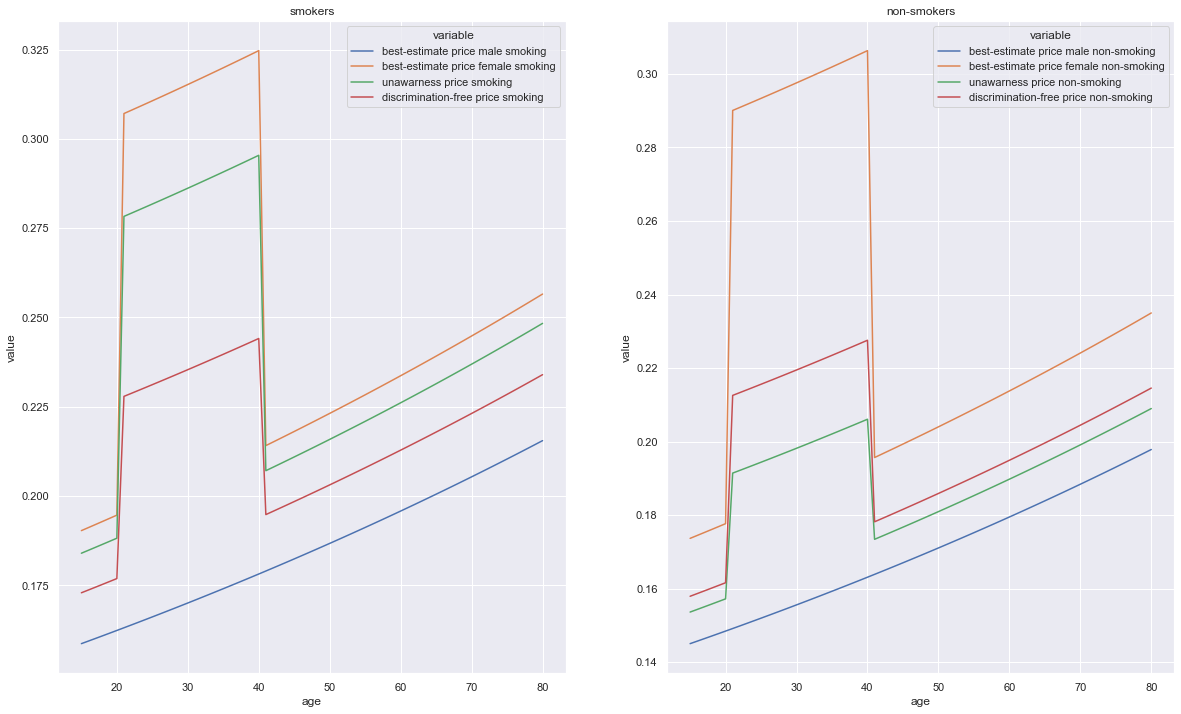

In [111]:
%matplotlib inline

sns.set(rc={'figure.figsize':(20,12)})

f, axes = plt.subplots(1, 2)


data_preproc_ns = pd.DataFrame({
    'age': age_range, 
    'best-estimate price male non-smoking': best_est_m_ns,
    'best-estimate price female non-smoking': best_est_f_ns,
    'unawarness price non-smoking': unawareness_price_ns,
    'discrimination-free price non-smoking': discr_free_price_ns})

data_preproc_s = pd.DataFrame({
    'age': age_range, 
    'best-estimate price male smoking': best_est_m_s,
    'best-estimate price female smoking': best_est_f_s,
    'unawarness price smoking': unawareness_price_s,
    'discrimination-free price smoking': discr_free_price_s})

plot_1 = sns.lineplot(x='age', y='value', hue='variable', 
             data=pd.melt(data_preproc_s, ['age']), ax = axes[0])
plot_1.set_title('smokers')

plot_2 = sns.lineplot(x='age', y='value', hue='variable', 
             data=pd.melt(data_preproc_ns, ['age']), ax = axes[1])
plot_2.set_title('non-smokers')

### 6. A more complicate example - simulated dataset

First, sample from variable Z with 4 levels: 
* level 0: male, non-smoker
* level 1: male, smoker
* level 2: female, non-smoker
* level 3: female, smoker

In [140]:
sim_size = 100000

z = np.random.choice(a = list(range(0,4)), size=sim_size, replace=True, p=[0.49, 0.06, 0.21, 0.24])

gender = np.where(((z == 0)|(z == 1)), 0, 1)
smoker = np.where(((z == 0)|(z == 2)), 0, 1)

In [141]:
pk = 1/70000 * ((np.array(range(15,81))-45)**2)*(-1) + 0.020
pk = 1/sum(pk) * pk
age = np.random.choice(a = list(range(15,81)), size=sim_size, replace=True, p=pk)

<AxesSubplot:xlabel='age', ylabel='value'>

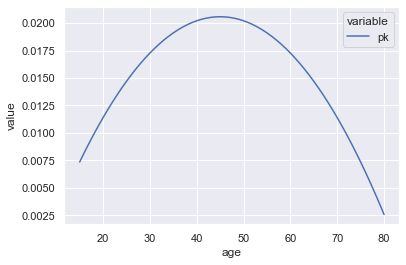

In [142]:
%matplotlib inline

data_preproc = pd.DataFrame({
    'age': list(range(15,81)), 
    'pk':pk})

sns.lineplot(x='age', y='value', hue='variable', 
             data=pd.melt(data_preproc, ['age']))

In [143]:
pregnant_age = np.where(((age > 19) & (age < 41)), 1, 0)

In [144]:
print(gender.shape, smoker.shape, age.shape, pregnant_age.shape)

(100000,) (100000,) (100000,) (100000,)


In [210]:
data_sim = pd.DataFrame({'gender':gender,
                         'smoker':smoker,
                         'age':age,
                         'pregnant_age':pregnant_age})

data_sim_backup = data_sim.copy(deep = True)

data_sim.head()

,gender,smoker,age,pregnant_age
0,1,0,47,0
1,0,0,51,0
2,1,0,24,1
3,0,0,18,0
4,0,0,63,0


##### 6.1 Simulate claim (type 1) observations $$log\lambda_{1}(\textbf{X},D):=\alpha_{0}+\alpha_{1}1_{X_1\in[20,40]}1_{D=woman}$$

In [146]:
claims_1 = np.random.poisson(np.exp(-40+38.5*pregnant_age*gender))

##### 6.2 Simulate claim (type 2) observations $$log\lambda_{2}(\textbf{X},D):=\beta_{0}+\beta_{1}X_{1}+\beta_{2}1_{X_2=smoker} + \beta_{3}1_{D=woman}$$


In [147]:
claims_2 = np.random.poisson(np.exp(-2+0.004*age+0.1*smoker+0.2*gender))

##### 6.3 Simulate claim (type 3) observations $$log\lambda_{3}(\textbf{X},D):=\gamma_{0}+\gamma_{1}X_{1}$$

In [148]:
claims_3 = np.random.poisson(np.exp(-2 + 0.01*age))

##### 6.4 Use Poisson GLM for each claim type

In [149]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

In [150]:
df_1 = pd.DataFrame({'claims_1':claims_1,
                   'age':age,
                   'smoker':smoker,
                   'gender':gender})

In [151]:
glm_type_1 = smf.glm(formula='claims_1 ~ 1 + age + smoker + gender', 
                     data = df_1, family= sm.families.Poisson()).fit()
est_freq_1 = glm_type_1.fittedvalues
print(glm_type_1.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:               claims_1   No. Observations:               100000
Model:                            GLM   Df Residuals:                    99996
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -11157.
Date:                Mon, 24 Jan 2022   Deviance:                       15816.
Time:                        16:17:36   Pearson chi2:                 3.47e+04
No. Iterations:                    28   Pseudo R-squ. (CS):            0.08468
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -28.8569   1.74e+04     -0.002      0.9

In [152]:
glm_type_1.predict().shape

(100000,)

In [153]:
np.mean((df_1['claims_1'] - glm_type_1.predict())**2)

0.039841637885993604

In [154]:
df_2 = pd.DataFrame({'claims_2':claims_2,
                   'age':age,
                   'smoker':smoker,
                   'gender':gender})

In [155]:
glm_type_2 = smf.glm(formula='claims_2 ~ 1 + age + smoker + gender', 
                     data = df_2, family= sm.families.Poisson()).fit()
est_freq_2 = glm_type_2.fittedvalues
print(glm_type_2.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:               claims_2   No. Observations:               100000
Model:                            GLM   Df Residuals:                    99996
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -50902.
Date:                Mon, 24 Jan 2022   Deviance:                       66840.
Time:                        16:17:36   Pearson chi2:                 9.96e+04
No. Iterations:                     6   Pseudo R-squ. (CS):           0.003531
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.9642      0.024    -82.628      0.0

In [156]:
df_3 = pd.DataFrame({'claims_3':claims_3,
                   'age':age,
                   'smoker':smoker,
                   'gender':gender})

In [157]:
glm_type_3 = smf.glm(formula='claims_3 ~ 1 + age + smoker + gender', 
                     data = df_2, family= sm.families.Poisson()).fit()
est_freq_3 = glm_type_3.fittedvalues
print(glm_type_3.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:               claims_3   No. Observations:               100000
Model:                            GLM   Df Residuals:                    99996
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -56061.
Date:                Mon, 24 Jan 2022   Deviance:                       72114.
Time:                        16:17:37   Pearson chi2:                 1.00e+05
No. Iterations:                     6   Pseudo R-squ. (CS):           0.004811
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.9790      0.022    -88.067      0.0

In [158]:
data_sim = pd.concat([data_sim, est_freq_1, est_freq_2, est_freq_3], axis = 1); data_sim.head()

,gender,smoker,age,pregnant_age,0,1,2
0,1,0,47,0,4.026775e-02,0.200503,0.218244
1,0,0,51,0,8.789649e-15,0.166761,0.221943
2,1,0,24,1,1.959213e-01,0.185454,0.176263
3,0,0,18,0,8.508352e-14,0.149101,0.163351
4,0,0,63,0,3.850099e-15,0.173690,0.248113


In [159]:
data_sim['gender'] = np.where(data_sim['gender'].astype(int) == 1, 'female', 'male')
data_sim['smoker'] = np.where(data_sim['smoker'].astype(int) == 1, 'smoker', 'non-smoker')

In [160]:
data_sim.head()

,gender,smoker,age,pregnant_age,0,1,2
0,female,non-smoker,47,0,4.026775e-02,0.200503,0.218244
1,male,non-smoker,51,0,8.789649e-15,0.166761,0.221943
2,female,non-smoker,24,1,1.959213e-01,0.185454,0.176263
3,male,non-smoker,18,0,8.508352e-14,0.149101,0.163351
4,male,non-smoker,63,0,3.850099e-15,0.173690,0.248113


Text(0.5, 1.0, 'claim_type_3')

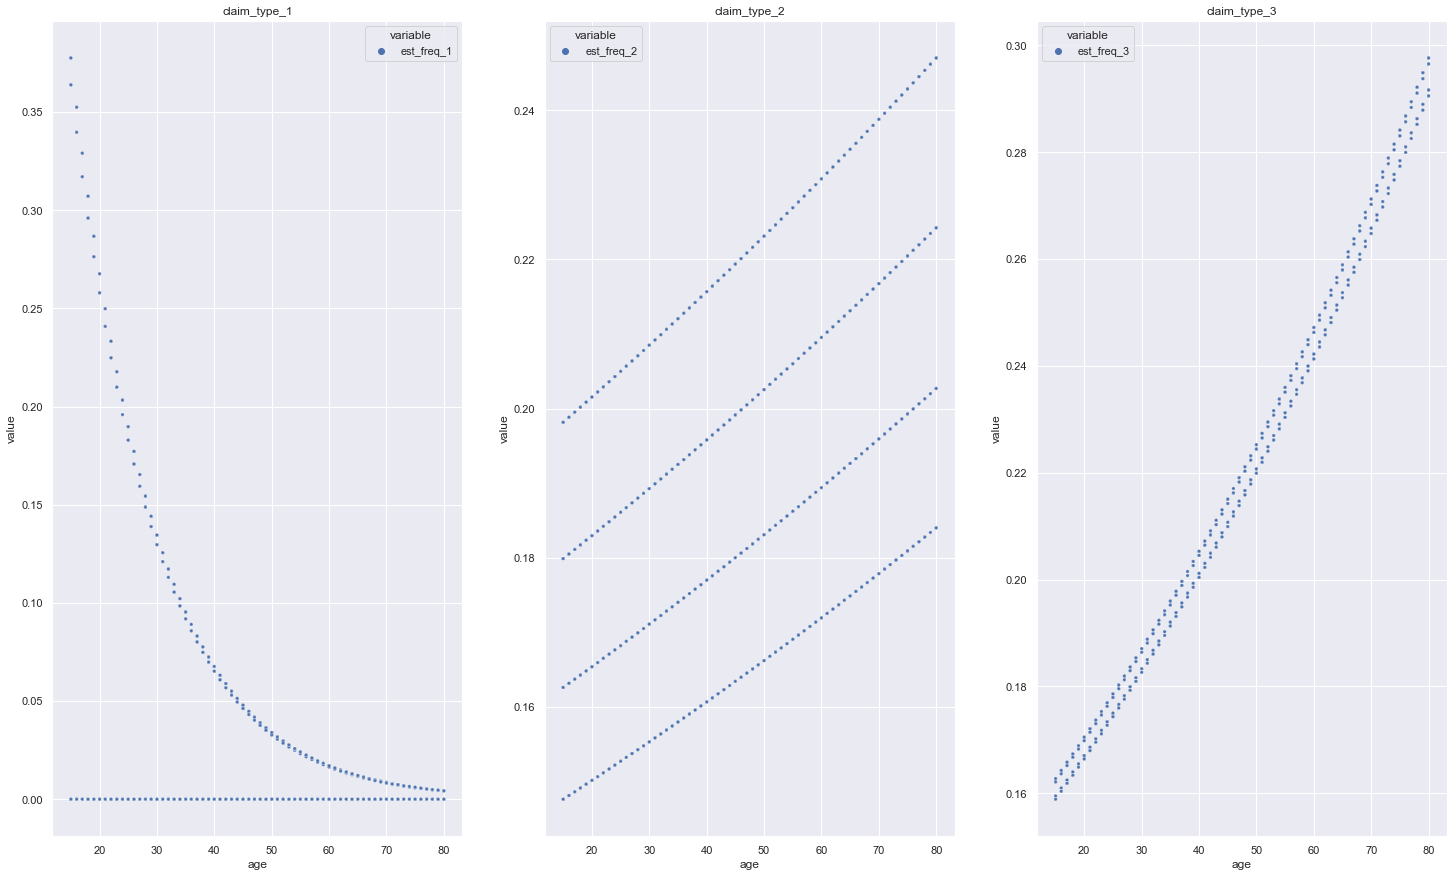

In [166]:
%matplotlib inline 

sns.set(rc={'figure.figsize':(25,15)})

#differenziare per colore
f, axes = plt.subplots(1, 3)

df_pre_1 = pd.DataFrame({
    'age': age, 
    'est_freq_1': est_freq_1})

df_pre_2 = pd.DataFrame({
    'age': age, 
    'est_freq_2': est_freq_2})

df_pre_3 = pd.DataFrame({
    'age': age, 
    'est_freq_3': est_freq_3})

plot_1 = sns.scatterplot(x='age', y='value', hue='variable', 
             data=pd.melt(df_pre_1, ['age']), ax = axes[0], s=10)
plot_1.set_title('claim_type_1')

plot_2 = sns.scatterplot(x='age', y='value', hue='variable', 
         data=pd.melt(df_pre_2, ['age']), ax = axes[1], s=10)
plot_2.set_title('claim_type_2')

plot_3 = sns.scatterplot(x='age', y='value', hue='variable', 
         data=pd.melt(df_pre_3, ['age']), ax = axes[2], s=10)
plot_3.set_title('claim_type_3')

### 7. Prices estimation - GLM

Let's recall that the claim amounts are assumed to be deterinistic and given by: $(c_{1}, c_{2}, c_{3} = 0.5, 0.9, 0.1)$.

##### 7.1 Best-estimate price

In [167]:
glm_type_1 = smf.glm(formula='claims_1 ~ 1 + age + smoker + gender', 
                     data = df_1, family= sm.families.Poisson()).fit()
est_freq_1 = glm_type_1.fittedvalues

glm_type_2 = smf.glm(formula='claims_2 ~ 1 + age + smoker + gender', 
                     data = df_2, family= sm.families.Poisson()).fit()
est_freq_2 = glm_type_2.fittedvalues

glm_type_3 = smf.glm(formula='claims_3 ~ 1 + age + smoker + gender', 
                     data = df_3, family= sm.families.Poisson()).fit()
est_freq_3 = glm_type_3.fittedvalues

best_est_price_glm = 0.5*est_freq_1 + 0.9*est_freq_2 + 0.1*est_freq_3

##### 7.2 Unawareness price

In [168]:
glm_type_1_unaware = smf.glm(formula='claims_1 ~ 1 + age + smoker', 
                     data = df_1, family= sm.families.Poisson()).fit()

est_freq_1_unaware = glm_type_1_unaware.fittedvalues

glm_type_2_unaware = smf.glm(formula='claims_2 ~ 1 + age + smoker', 
                     data = df_2, family= sm.families.Poisson()).fit()

est_freq_2_unaware = glm_type_2_unaware.fittedvalues

glm_type_3_unaware = smf.glm(formula='claims_3 ~ 1 + age + smoker', 
                     data = df_3, family= sm.families.Poisson()).fit()

est_freq_3_unaware = glm_type_3_unaware.fittedvalues

unaware_price_glm = 0.5*est_freq_1_unaware + 0.9*est_freq_2_unaware + 0.1*est_freq_3_unaware

##### 7.3 Discrimination-free price

In [169]:
theta3_type1 = glm_type_1.params[-1]
theta3_type2 = glm_type_2.params[-1] 
theta3_type3 = glm_type_3.params[-1]
print(theta3_type1, theta3_type2, theta3_type3)

28.877838564179953 0.19783139858071994 0.02034784495771977


In [170]:
n = sim_size
nfemale = np.sum(gender)
nmale = len(gender) - nfemale

est_freq_1_discr_free = np.where((gender == 1), est_freq_1*(nfemale/n) + (est_freq_1/np.exp(theta3_type1))*(nmale/n),
                                              est_freq_1*(nmale/n) + (est_freq_1*np.exp(theta3_type1))*(nfemale/n))
est_freq_2_discr_free = np.where((gender == 1), est_freq_2*(nfemale/n) + (est_freq_2/np.exp(theta3_type2))*(nmale/n),
                                              est_freq_2*(nmale/n) + (est_freq_2*np.exp(theta3_type2))*(nfemale/n))
est_freq_3_discr_free = np.where((gender == 1), est_freq_3*(nfemale/n) + (est_freq_3/np.exp(theta3_type3))*(nmale/n),
                                              est_freq_3*(nmale/n) + (est_freq_3*np.exp(theta3_type3))*(nfemale/n))

discr_free_price_glm = 0.5*est_freq_1_discr_free + 0.9*est_freq_2_discr_free + 0.1*est_freq_3_discr_free

##### 7.4 Aggregate prices

In [188]:
prices_agg = pd.concat([data_sim, pd.Series(best_est_price_glm), 
                        pd.Series(unaware_price_glm), pd.Series(discr_free_price_glm)], axis = 1)
prices_agg.columns = ['gender','smoker','age','pregnant_age',
                      'est_freq_1','est_freq_2','est_freq_3',
                      'best_est_price_glm','unaware_price_glm','discr_free_price_glm']
prices_agg.head()

,gender,smoker,age,pregnant_age,est_freq_1,est_freq_2,est_freq_3,best_est_price_glm,unaware_price_glm,discr_free_price_glm
0,female,non-smoker,47,0,4.026775e-02,0.200503,0.218244,0.222411,0.185462,0.193393
1,male,non-smoker,51,0,8.789649e-15,0.166761,0.221943,0.172280,0.186965,0.194243
2,female,non-smoker,24,1,1.959213e-01,0.185454,0.176263,0.282496,0.192982,0.212215
3,male,non-smoker,18,0,8.508352e-14,0.149101,0.163351,0.150526,0.204177,0.230868
4,male,non-smoker,63,0,3.850099e-15,0.173690,0.248113,0.181132,0.193636,0.199851


In [189]:
prices_agg['best-estimate price female glm'] = prices_agg[prices_agg.gender == 'female'].best_est_price_glm
prices_agg['best-estimate price male glm'] = prices_agg[prices_agg.gender == 'male'].best_est_price_glm
prices_agg = prices_agg.drop('best_est_price_glm',1)
prices_agg = prices_agg.rename(columns={'unaware_price_glm':'unaware price glm',
                                'discr_free_price_glm':'discrimination-free price glm'})

C:\Users\u0149060\Anaconda3\envs\dev_env\lib\site-packages\ipykernel_launcher.py:3: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only
  This is separate from the ipykernel package so we can avoid doing imports until


Text(0.5, 1.0, 'non-smokers')

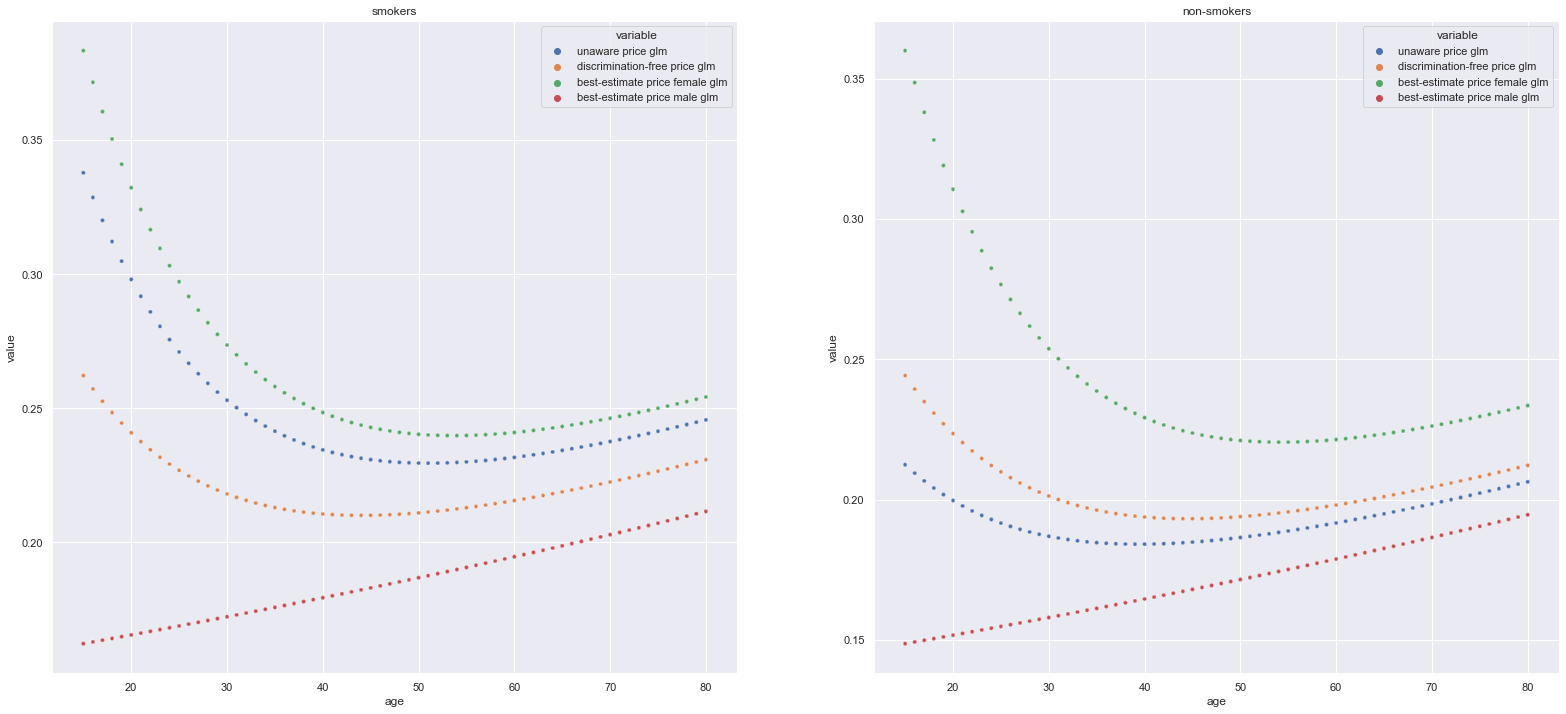

In [190]:
%matplotlib inline 

sns.set(rc={'figure.figsize':(27,12)})
f, axes = plt.subplots(1, 2)

df_smok = prices_agg[prices_agg.smoker == 'smoker']
df_smok = df_smok.drop(['smoker','gender','pregnant_age','est_freq_1','est_freq_2','est_freq_3'], axis = 1)

df_nnsmok = prices_agg[prices_agg.smoker != 'smoker']
df_nnsmok = df_nnsmok.drop(['smoker','gender','pregnant_age','est_freq_1','est_freq_2','est_freq_3'], axis = 1)

plot_1 = sns.scatterplot(x='age', y='value', hue='variable', 
             data=pd.melt(df_smok, ['age']), ax = axes[0], s=15)
plot_1.set_title('smokers')

plot_2 = sns.scatterplot(x='age', y='value', hue='variable', 
         data=pd.melt(df_nnsmok, ['age']), ax = axes[1], s=15)
plot_2.set_title('non-smokers')

### 8. Neural Network Estimation via Tensorflow

In [375]:
data_sim_nn = data_sim_backup.drop(['pregnant_age'],1)

C:\Users\u0149060\Anaconda3\envs\dev_env\lib\site-packages\ipykernel_launcher.py:1: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only
  """Entry point for launching an IPython kernel.


In [376]:
# neural network initialization
def init_network(optim = 'Adam'):
    model = tf.keras.models.Sequential()
    model.add(tf.keras.layers.InputLayer(input_shape=(3,)))
    model.add(tf.keras.layers.Dense(units = 15, activation = 'relu'))
    model.add(tf.keras.layers.Dense(units = 15, activation = 'relu'))
    model.add(tf.keras.layers.Dense(units = 1, activation = 'exponential'))
    model.compile(optimizer = optim, loss = 'poisson')
    return model

In [377]:
claim_type_1 = init_network()
claim_type_2 = init_network()
claim_type_3 = init_network()

In [378]:
# fit the neural netword
claim_type_1.fit(x = data_sim_nn,
               y = claims_1,
               epochs = 1000,
               batch_size = 25000,
               validation_split = 0,
               verbose = 0)

In [379]:
claim_type_2.fit(x = data_sim_nn,
               y = claims_2,
               epochs = 1000,
               batch_size = 25000,
               validation_split = 0,
               verbose = 0)

In [380]:
claim_type_3.fit(x = data_sim_nn,
               y = claims_3,
               epochs = 1000,
               batch_size = 25000,
               validation_split = 0,
               verbose = 0)

In [381]:
data_sim_nn_with_estimates = data_sim_nn.copy(deep = True)
data_sim_nn_with_estimates['est_freq_1'] = claim_type_1.predict(data_sim_nn)
data_sim_nn_with_estimates['est_freq_2'] = claim_type_2.predict(data_sim_nn)
data_sim_nn_with_estimates['est_freq_3'] = claim_type_3.predict(data_sim_nn)
data_sim_nn_with_estimates

,gender,smoker,age,est_freq_1,est_freq_2,est_freq_3
0,1,0,47,2.859658e-03,0.190365,0.217847
1,0,0,51,3.331174e-12,0.157725,0.222369
2,1,0,24,2.322644e-01,0.180693,0.174049
3,0,0,18,2.309648e-04,0.146354,0.168168
4,0,0,63,4.363299e-15,0.162075,0.249997
...,...,...,...,...,...,...
99995,0,0,70,9.082239e-17,0.164668,0.267671
99996,1,0,26,2.320528e-01,0.181514,0.177479
99997,0,1,33,6.517000e-08,0.166754,0.189233
99998,1,1,66,9.089264e-08,0.218876,0.266007


Creating custom ```pd.DataFrame``` to plot in a clear way: 

In [389]:
claim_type_1 = data_sim_nn_with_estimates.copy(deep = True)
claim_type_1 = claim_type_1[['gender','smoker','age','est_freq_1']]
claim_type_1['best-estimate price female smoker nn'] = claim_type_1[(claim_type_1.gender == 1) & (claim_type_1.smoker == 1)].est_freq_1
claim_type_1['best-estimate price female non-smoker nn'] = claim_type_1[(claim_type_1.gender == 1) & (claim_type_1.smoker == 0)].est_freq_1
claim_type_1['best-estimate price male smoker nn'] = claim_type_1[(claim_type_1.gender == 0) & (claim_type_1.smoker == 1)].est_freq_1
claim_type_1['best-estimate price male non-smoker nn'] = claim_type_1[(claim_type_1.gender == 0) & (claim_type_1.smoker == 0)].est_freq_1
claim_type_1 = claim_type_1.drop(['gender','smoker','est_freq_1'],1)

C:\Users\u0149060\Anaconda3\envs\dev_env\lib\site-packages\ipykernel_launcher.py:7: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only
  import sys


In [390]:
claim_type_2 = data_sim_nn_with_estimates.copy(deep = True)
claim_type_2 = claim_type_2[['gender','smoker','age','est_freq_2']]
claim_type_2['best-estimate price female smoker nn'] = claim_type_2[(claim_type_2.gender == 1) & (claim_type_2.smoker == 1)].est_freq_2
claim_type_2['best-estimate price female non-smoker nn'] = claim_type_2[(claim_type_2.gender == 1) & (claim_type_2.smoker == 0)].est_freq_2
claim_type_2['best-estimate price male smoker nn'] = claim_type_2[(claim_type_2.gender == 0) & (claim_type_2.smoker == 1)].est_freq_2
claim_type_2['best-estimate price male non-smoker nn'] = claim_type_2[(claim_type_2.gender == 0) & (claim_type_2.smoker == 0)].est_freq_2
claim_type_2 = claim_type_2.drop(['gender','smoker','est_freq_2'],1)

C:\Users\u0149060\Anaconda3\envs\dev_env\lib\site-packages\ipykernel_launcher.py:7: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only
  import sys


In [391]:
claim_type_3 = data_sim_nn_with_estimates.copy(deep = True)
claim_type_3 = claim_type_3[['gender','smoker','age','est_freq_3']]
claim_type_3['best-estimate price female smoker nn'] = claim_type_3[(claim_type_3.gender == 1) & (claim_type_3.smoker == 1)].est_freq_3
claim_type_3['best-estimate price female non-smoker nn'] = claim_type_3[(claim_type_3.gender == 1) & (claim_type_3.smoker == 0)].est_freq_3
claim_type_3['best-estimate price male smoker nn'] = claim_type_3[(claim_type_3.gender == 0) & (claim_type_3.smoker == 1)].est_freq_3
claim_type_3['best-estimate price male non-smoker nn'] = claim_type_3[(claim_type_3.gender == 0) & (claim_type_3.smoker == 0)].est_freq_3
claim_type_3 = claim_type_3.drop(['gender','smoker','est_freq_3'],1)

C:\Users\u0149060\Anaconda3\envs\dev_env\lib\site-packages\ipykernel_launcher.py:7: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only
  import sys


[]

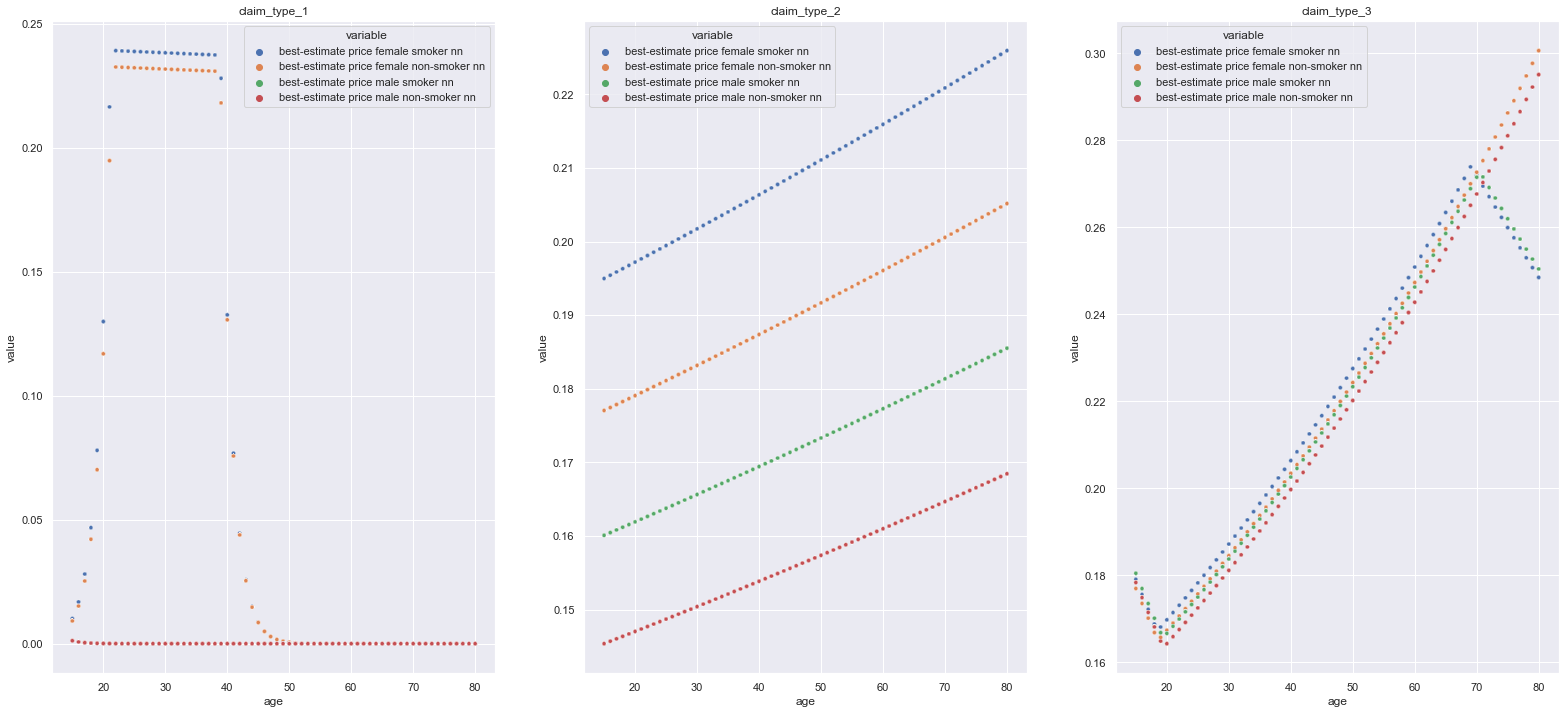

In [394]:
%matplotlib inline 

sns.set(rc={'figure.figsize':(27,12)})
f, axes = plt.subplots(1, 3)

plot_1 = sns.scatterplot(x='age', y='value', hue='variable', 
         data=pd.melt(claim_type_1, ['age']), ax = axes[0], s=15)
plot_1.set_title('claim_type_1')

plot_2 = sns.scatterplot(x='age', y='value', hue='variable', 
         data=pd.melt(claim_type_2, ['age']), ax = axes[1], s=15)
plot_2.set_title('claim_type_2')

plot_3 = sns.scatterplot(x='age', y='value', hue='variable', 
         data=pd.melt(claim_type_3, ['age']), ax = axes[2], s=15)
plot_3.set_title('claim_type_3')

# Chapter 3 - Application using machine learning methods <a name="three"></a>

In [191]:
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import HistGradientBoostingRegressor

# claims_1
y_1 = df_1.claims_1
x_1 = df_1[['age','smoker','gender']]

ensemble_1 = HistGradientBoostingRegressor(max_depth=1, 
                                         learning_rate=0.75,
                                         loss="poisson").fit(x_1, y_1)

pred_gbm_1_sm_women = ensemble_1.predict(pd.DataFrame({"age":list(range(15,81)), 
                               "smoker":np.repeat(1,66), 
                               "gender":np.repeat(1,66)}))
pred_gbm_1_nsm_women = ensemble_1.predict(pd.DataFrame({"age":list(range(15,81)), 
                               "smoker":np.repeat(0,66), 
                               "gender":np.repeat(1,66)}))
pred_gbm_1_sm_men = ensemble_1.predict(pd.DataFrame({"age":list(range(15,81)), 
                               "smoker":np.repeat(1,66), 
                               "gender":np.repeat(0,66)}))
pred_gbm_1_nsm_men = ensemble_1.predict(pd.DataFrame({"age":list(range(15,81)), 
                               "smoker":np.repeat(0,66), 
                               "gender":np.repeat(0,66)}))

C:\Users\u0149060\Anaconda3\envs\dev_env\lib\site-packages\sklearn\experimental\enable_hist_gradient_boosting.py:17: UserWarning: Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.
  "Since version 1.0, "


<AxesSubplot:xlabel='age', ylabel='value'>

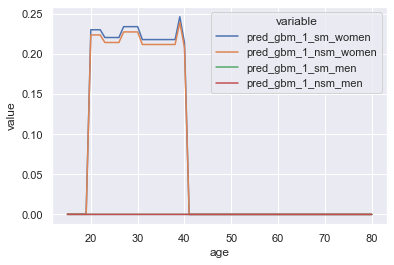

In [192]:
%matplotlib inline

data_preproc = pd.DataFrame({
    'age': list(range(15,81)), 
    'pred_gbm_1_sm_women': pred_gbm_1_sm_women,
    'pred_gbm_1_nsm_women': pred_gbm_1_nsm_women,
    'pred_gbm_1_sm_men': pred_gbm_1_sm_men,
    'pred_gbm_1_nsm_men': pred_gbm_1_nsm_men})

sns.lineplot(x='age', y='value', hue='variable', 
             data=pd.melt(data_preproc, ['age']))

In [193]:
# claims_2

y_2 = df_2.claims_2
x_2 = df_2[['age','smoker','gender']]

ensemble_2 = HistGradientBoostingRegressor(max_depth=1, 
                                         learning_rate=0.75,
                                         loss="poisson").fit(x_2, y_2)

pred_gbm_2_sm_women = ensemble_2.predict(pd.DataFrame({"age":list(range(15,81)), 
                               "smoker":np.repeat(1,66), 
                               "gender":np.repeat(1,66)}))
pred_gbm_2_nsm_women = ensemble_2.predict(pd.DataFrame({"age":list(range(15,81)), 
                               "smoker":np.repeat(0,66), 
                               "gender":np.repeat(1,66)}))
pred_gbm_2_sm_men = ensemble_2.predict(pd.DataFrame({"age":list(range(15,81)), 
                               "smoker":np.repeat(1,66), 
                               "gender":np.repeat(0,66)}))
pred_gbm_2_nsm_men = ensemble_2.predict(pd.DataFrame({"age":list(range(15,81)), 
                               "smoker":np.repeat(0,66), 
                               "gender":np.repeat(0,66)}))

<AxesSubplot:xlabel='age', ylabel='value'>

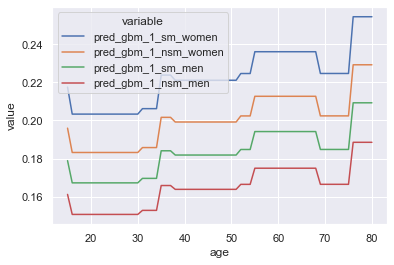

In [194]:
%matplotlib inline

data_preproc = pd.DataFrame({
    'age': list(range(15,81)), 
    'pred_gbm_1_sm_women': pred_gbm_2_sm_women,
    'pred_gbm_1_nsm_women': pred_gbm_2_nsm_women,
    'pred_gbm_1_sm_men': pred_gbm_2_sm_men,
    'pred_gbm_1_nsm_men': pred_gbm_2_nsm_men})

sns.lineplot(x='age', y='value', hue='variable', 
             data=pd.melt(data_preproc, ['age']))

In [195]:
# claims_3

y_3 = df_3.claims_3
x_3 = df_3[['age','smoker','gender']]

ensemble_3 = HistGradientBoostingRegressor(max_depth=1, 
                                         learning_rate=0.75,
                                         loss="poisson").fit(x_3, y_3)

pred_gbm_3_sm_women = ensemble_3.predict(pd.DataFrame({"age":list(range(15,81)), 
                               "smoker":np.repeat(1,66), 
                               "gender":np.repeat(1,66)}))
pred_gbm_3_nsm_women = ensemble_3.predict(pd.DataFrame({"age":list(range(15,81)), 
                               "smoker":np.repeat(0,66), 
                               "gender":np.repeat(1,66)}))
pred_gbm_3_sm_men = ensemble_3.predict(pd.DataFrame({"age":list(range(15,81)), 
                               "smoker":np.repeat(1,66), 
                               "gender":np.repeat(0,66)}))
pred_gbm_3_nsm_men = ensemble_3.predict(pd.DataFrame({"age":list(range(15,81)), 
                               "smoker":np.repeat(0,66), 
                               "gender":np.repeat(0,66)}))

<AxesSubplot:xlabel='age', ylabel='value'>

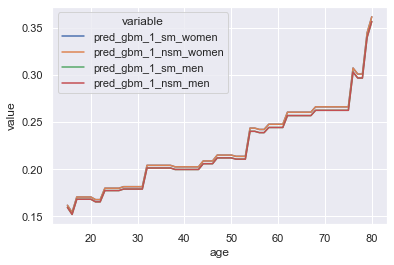

In [196]:
%matplotlib inline

data_preproc = pd.DataFrame({
    'age': list(range(15,81)), 
    'pred_gbm_1_sm_women': pred_gbm_3_sm_women,
    'pred_gbm_1_nsm_women': pred_gbm_3_nsm_women,
    'pred_gbm_1_sm_men': pred_gbm_3_sm_men,
    'pred_gbm_1_nsm_men': pred_gbm_3_nsm_men})

sns.lineplot(x='age', y='value', hue='variable', 
             data=pd.melt(data_preproc, ['age']))

In [197]:
### Best-estimate price
gbm_best_est_f_ns = 0.5*pred_gbm_1_nsm_women + 0.9*pred_gbm_2_nsm_women + 0.1*pred_gbm_3_nsm_women
gbm_best_est_f_s = 0.5*pred_gbm_1_sm_women + 0.9*pred_gbm_2_sm_women + 0.1*pred_gbm_3_sm_women
gbm_best_est_m_ns = 0.5*pred_gbm_1_nsm_men + 0.9*pred_gbm_2_nsm_men + 0.1*pred_gbm_3_nsm_men
gbm_best_est_m_s = 0.5*pred_gbm_1_sm_men + 0.9*pred_gbm_2_sm_men + 0.1*pred_gbm_3_sm_men

In [198]:
### Unawareness price

# Type 1
y_1 = df_1.claims_1
x_1 = df_1[['age','smoker']]
gbm_1_unaware = HistGradientBoostingRegressor(max_depth=1, 
                                         learning_rate=0.75,
                                         loss="poisson").fit(x_1, y_1)

pred_1_unaware_s = gbm_1_unaware.predict(pd.DataFrame({"age":list(range(15,81)), "smoker":np.repeat(1,66)}))
pred_1_unaware_ns = gbm_1_unaware.predict(pd.DataFrame({"age":list(range(15,81)), "smoker":np.repeat(0,66)}))

# Type 2
y_2 = df_2.claims_2
x_2 = df_2[['age','smoker']]

gbm_2_unaware = HistGradientBoostingRegressor(max_depth=1, 
                                         learning_rate=0.75,
                                         loss="poisson").fit(x_2, y_2)

pred_2_unaware_s = gbm_2_unaware.predict(pd.DataFrame({"age":list(range(15,81)), "smoker":np.repeat(1,66)}))
pred_2_unaware_ns = gbm_2_unaware.predict(pd.DataFrame({"age":list(range(15,81)), "smoker":np.repeat(0,66)}))

# Type 3
y_3 = df_3.claims_3
x_3 = df_3[['age','smoker']]

gbm_3_unaware = HistGradientBoostingRegressor(max_depth=1, 
                                         learning_rate=0.75,
                                         loss="poisson").fit(x_3, y_3)

pred_3_unaware_s = gbm_3_unaware.predict(pd.DataFrame({"age":list(range(15,81)), "smoker":np.repeat(1,66)}))
pred_3_unaware_ns = gbm_3_unaware.predict(pd.DataFrame({"age":list(range(15,81)), "smoker":np.repeat(0,66)}))

In [199]:
# Price calculation
gbm_unaware_s = 0.5*pred_1_unaware_s + 0.9*pred_2_unaware_s + 0.1*pred_3_unaware_s #for smoker
gbm_unaware_ns = 0.5*pred_1_unaware_ns + 0.9*pred_2_unaware_ns + 0.1*pred_3_unaware_ns #for non-smokers

In [200]:
### Discrimination-free price
ratio_female = sum(gender)/sim_size
ratio_male = 1-ratio_female

discr_free_type1_s = pred_gbm_1_sm_women*ratio_female + pred_gbm_1_sm_men*ratio_male
discr_free_type1_ns = pred_gbm_1_nsm_women*ratio_female + pred_gbm_1_nsm_men*ratio_male

discr_free_type2_s = pred_gbm_2_sm_women*ratio_female + pred_gbm_2_sm_men*ratio_male
discr_free_type2_ns = pred_gbm_2_nsm_women*ratio_female + pred_gbm_2_nsm_men*ratio_male

discr_free_type3_s = pred_gbm_3_sm_women*ratio_female + pred_gbm_3_sm_men*ratio_male
discr_free_type3_ns = pred_gbm_3_nsm_women*ratio_female + pred_gbm_3_nsm_men*ratio_male

In [201]:
gbm_discr_free_s = 0.5*discr_free_type1_s + 0.9*discr_free_type2_s + 0.1*discr_free_type3_s #for smokers
gbm_discr_free_ns = 0.5*discr_free_type1_ns + 0.9*discr_free_type2_ns + 0.1*discr_free_type3_ns #for non-smokers

In [202]:
%matplotlib inline 

df_gbm_no_smok = pd.concat([pd.DataFrame({'age':list(range(15,81))}),
                                            pd.Series(gbm_best_est_f_ns),
                                            pd.Series(gbm_best_est_f_ns),
                                            pd.Series(gbm_unaware_ns),
                                            pd.Series(gbm_discr_free_ns)], axis = 1)

df_gbm_smok = pd.concat([pd.DataFrame({'age':list(range(15,81))}), 
                                        pd.Series(gbm_best_est_f_ns),
                                        pd.Series(gbm_best_est_f_ns),
                                        pd.Series(gbm_unaware_ns),
                                        pd.Series(gbm_discr_free_ns)], axis = 1)

<AxesSubplot:xlabel='age', ylabel='value'>

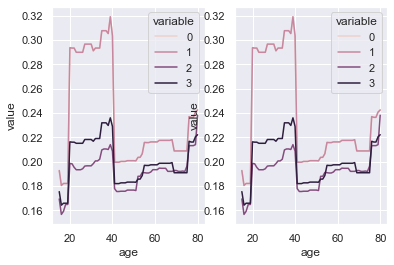

In [203]:
%matplotlib inline

f, axes = plt.subplots(1, 2)

sns.lineplot(x='age', y='value', hue='variable',
             data=pd.melt(df_gbm_no_smok, ['age']), ax = axes[0])

sns.lineplot(x='age', y='value', hue='variable', 
         data=pd.melt(df_gbm_smok, ['age']), ax = axes[1])